In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv(r"C:\Users\Rahul\Desktop\Codes\aiml\Machine Learning\LinearRegression\CarPricePrediction\Data\cardekho_dataset.csv")

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15244.0,6.041131,3.016228,0.0,4.0,6.00,8.0,29.00
km_driven,15244.0,55639.582327,51766.299327,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15244.0,19.697333,4.169307,4.0,17.0,19.67,22.7,33.54
engine,15244.0,1486.171543,520.419390,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15244.0,100.607652,42.915687,38.4,74.0,88.50,117.3,626.00
seats,15244.0,5.326161,0.808760,0.0,5.0,5.00,5.0,9.00
selling_price,15244.0,774701.448111,894676.081921,40000.0,385000.0,559000.00,825000.0,39500000.00


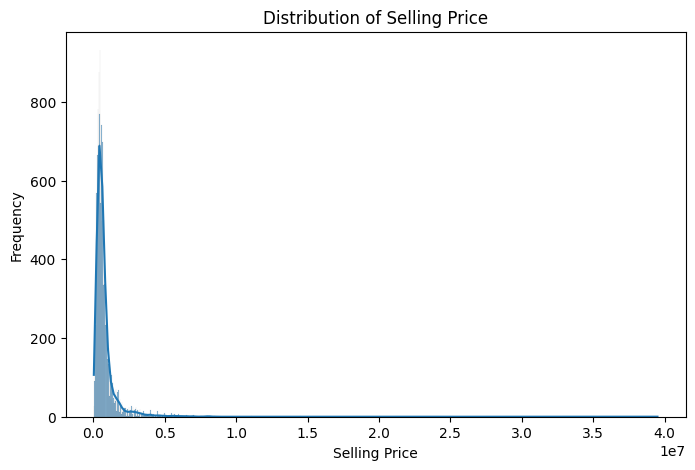

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(df["selling_price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

In [24]:
print("Selling price skewness:", df["selling_price"].skew())

Selling price skewness: 10.10889556800239


Numerical correlations

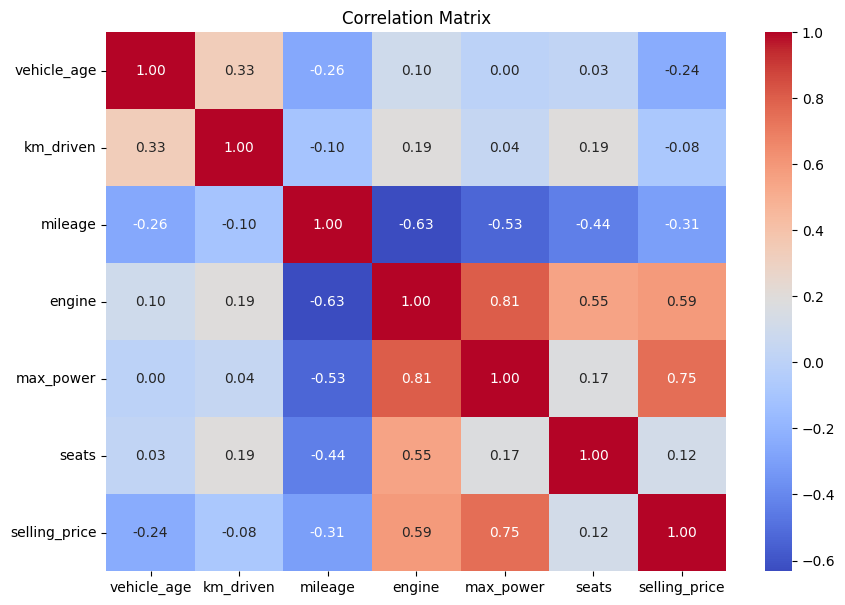

In [25]:
plt.figure(figsize=(10, 7))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

Price vs important numerical variables

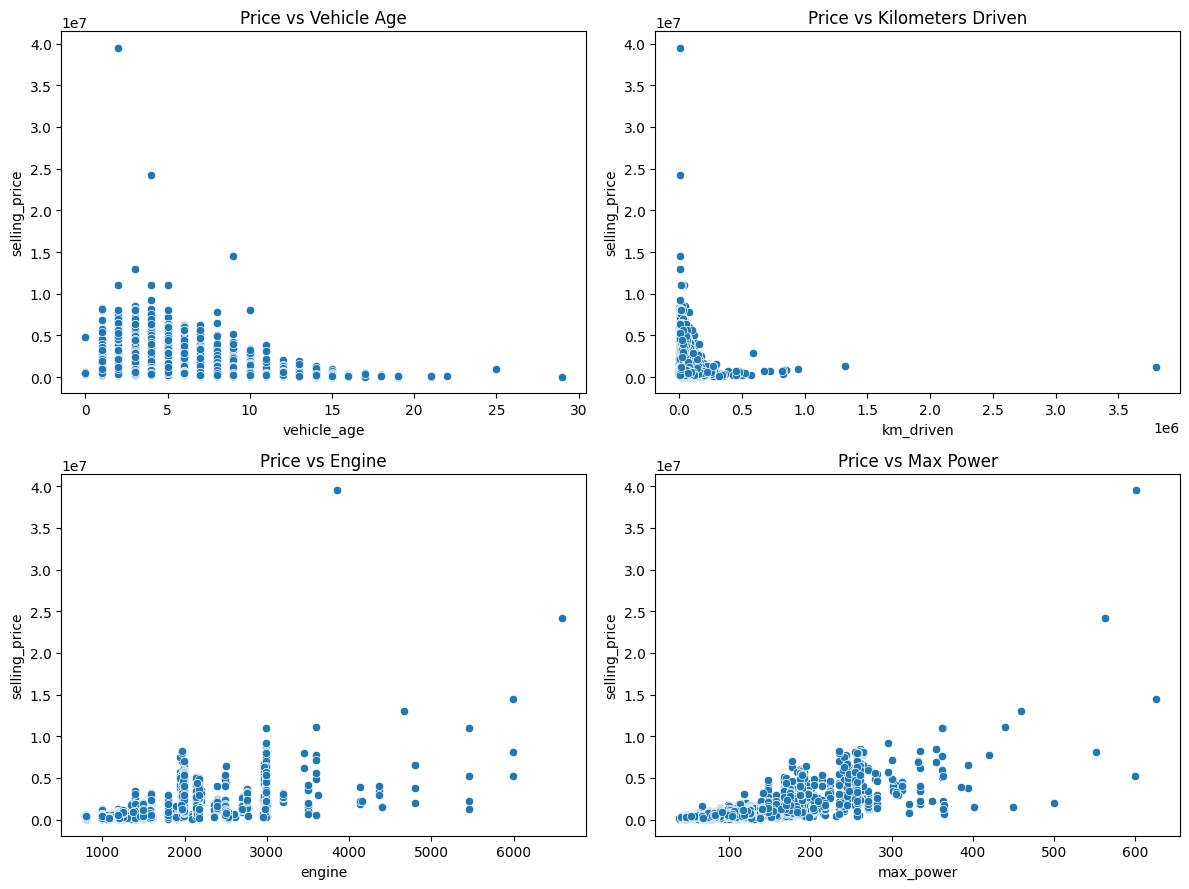

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(data=df, x="vehicle_age", y="selling_price", ax=axes[0, 0])
axes[0, 0].set_title("Price vs Vehicle Age")

sns.scatterplot(data=df, x="km_driven", y="selling_price", ax=axes[0, 1])
axes[0, 1].set_title("Price vs Kilometers Driven")

sns.scatterplot(data=df, x="engine", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Price vs Engine")

sns.scatterplot(data=df, x="max_power", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Price vs Max Power")

plt.tight_layout()
plt.show()

Categorical features vs price

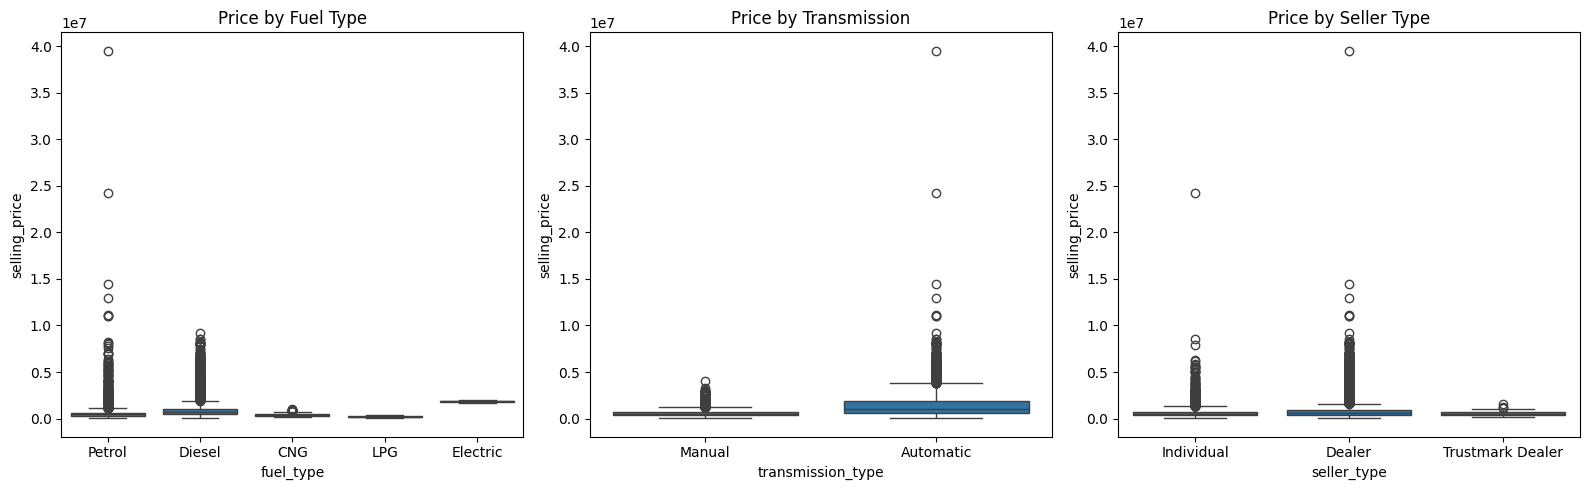

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="fuel_type", y="selling_price", ax=axes[0])
axes[0].set_title("Price by Fuel Type")

sns.boxplot(data=df, x="transmission_type", y="selling_price", ax=axes[1])
axes[1].set_title("Price by Transmission")

sns.boxplot(data=df, x="seller_type", y="selling_price", ax=axes[2])
axes[2].set_title("Price by Seller Type")

plt.tight_layout()
plt.show()

Check numerical outliers quickly

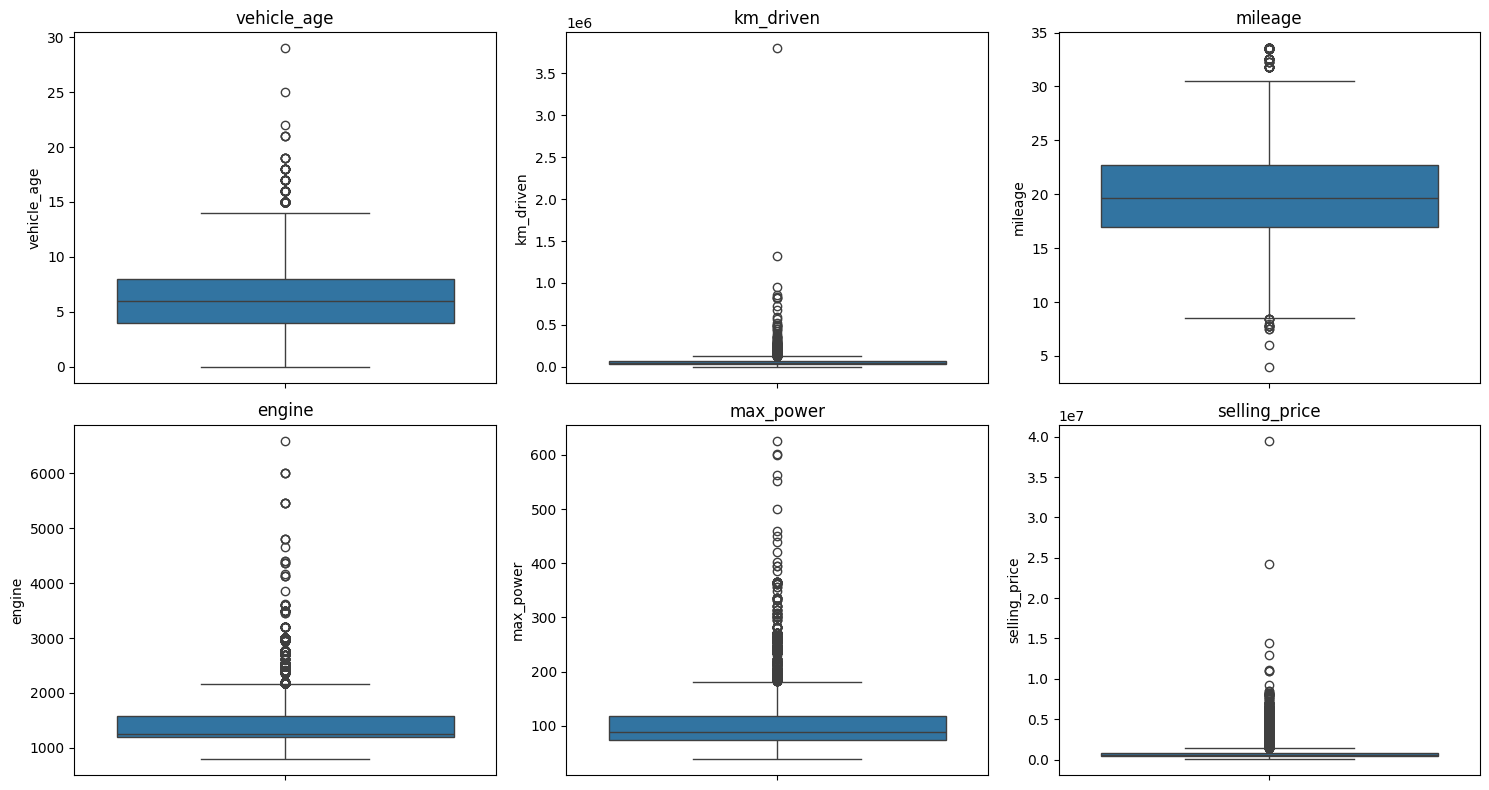

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cols = ["vehicle_age", "km_driven", "mileage",
        "engine", "max_power", "selling_price"]

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [29]:
for col in ["seller_type", "fuel_type", "transmission_type"]:
    print(f"\n{col}")
    print(df.groupby(col)["selling_price"].agg(
        ["count", "mean", "median"]
    ).sort_values("median", ascending=False))


seller_type
                  count           mean    median
seller_type                                     
Dealer             9459  870400.888043  590000.0
Trustmark Dealer    173  571959.537572  540000.0
Individual         5612  619650.369743  510000.0

fuel_type
           count          mean     median
fuel_type                                
Electric       4  1.853500e+06  1857500.0
Diesel      7342  1.000458e+06   700000.0
Petrol      7555  5.721783e+05   460000.0
CNG          299  4.176890e+05   370000.0
LPG           44  2.062727e+05   182500.0

transmission_type
                   count          mean     median
transmission_type                                
Automatic           3150  1.577104e+06  1050000.0
Manual             12094  5.657079e+05   500000.0


In [30]:
df.nlargest(10, "selling_price")[
    ["brand", "model", "vehicle_age", "km_driven",
     "engine", "max_power", "selling_price"]
]

,brand,model,vehicle_age,km_driven,engine,max_power,selling_price
3785,Ferrari,GTC4Lusso,2,3800,3855,601.00,39500000
10870,Rolls-Royce,Ghost,4,5000,6592,563.00,24200000
1170,Bentley,Continental,9,9000,5998,626.00,14500000
9637,Mercedes-Benz,S-Class,3,4000,4663,459.00,13000000
9283,Porsche,Cayenne,4,24000,3604,440.00,11100000
1882,Mercedes-Benz,S-Class,5,41000,5461,362.90,11000000
10890,Mercedes-Benz,S-Class,2,18000,2996,362.07,11000000
10900,Land Rover,Rover,4,9500,2993,296.00,9200000
3087,BMW,7,3,50000,2993,261.49,8500000
8376,BMW,7,3,19000,2993,355.37,8500000


In [31]:
model_stats = (
    df.groupby("model")["selling_price"]
      .agg(["count", "mean", "median"])
      .sort_values("median", ascending=False)
)

display(model_stats.head(20))

,count,mean,median
model,,,
GTC4Lusso,1,3.950000e+07,39500000.0
Ghost,1,2.420000e+07,24200000.0
Continental,3,9.266667e+06,8100000.0
RX,2,7.100000e+06,7100000.0
GLS,12,6.781083e+06,6950000.0
Ghibli,1,6.200000e+06,6200000.0
Quattroporte,1,6.000000e+06,6000000.0
Macan,2,5.985000e+06,5985000.0
X4,6,5.570000e+06,5600000.0


In [32]:
display(
    df["model"].value_counts().head(20)
)

model
i20            898
Swift Dzire    875
Swift          774
Alto           768
City           750
Wagon R        709
Grand          569
Innova         544
Verna          488
i10            406
Ecosport       371
Polo           369
Baleno         362
Amaze          360
Ciaz           343
Ertiga         341
Creta          335
XUV500         327
KWID           299
Vitara         289
Name: count, dtype: int64

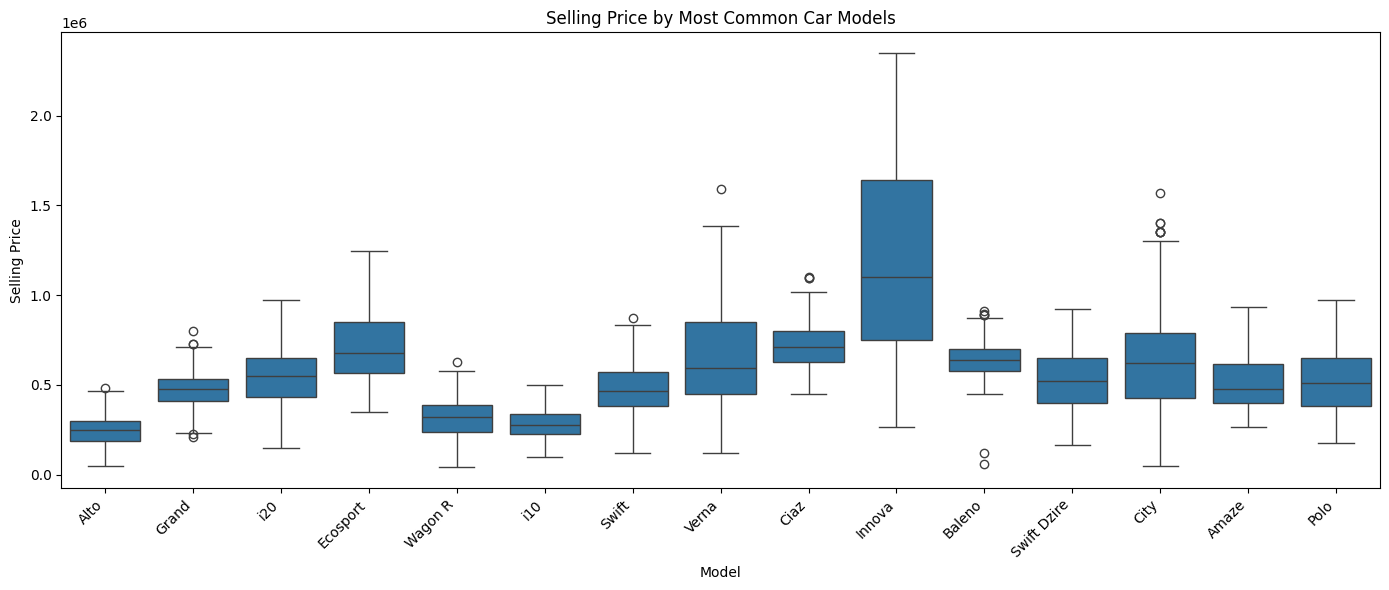

In [33]:
top_models = df["model"].value_counts().head(15).index

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df[df["model"].isin(top_models)],
    x="model",
    y="selling_price"
)

plt.xticks(rotation=45, ha="right")
plt.title("Selling Price by Most Common Car Models")
plt.xlabel("Model")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

In [34]:
# Check suspicious zero/negative values
for col in ["vehicle_age", "km_driven", "mileage", "engine",
            "max_power", "seats", "selling_price"]:
    print(f"{col}: {(df[col] <= 0).sum()} values <= 0")


# Inspect rows with invalid seat count
df[df["seats"] <= 0]



df.nlargest(10, "km_driven")[
    ["brand", "model", "vehicle_age", "km_driven",
     "selling_price"]
]

vehicle_age: 4 values <= 0
km_driven: 0 values <= 0
mileage: 0 values <= 0
engine: 0 values <= 0
max_power: 0 values <= 0
seats: 2 values <= 0
selling_price: 0 values <= 0


,brand,model,vehicle_age,km_driven,selling_price
15242,Mahindra,XUV500,5,3800000,1225000
11790,Mercedes-Benz,E-Class,9,1325000,1350000
8701,Toyota,Innova,6,950000,950000
4516,Renault,Duster,4,850000,850000
6673,Volkswagen,Vento,9,830000,380000
10742,Hyundai,Creta,6,825000,825000
11508,Volkswagen,Polo,5,820000,695000
7276,Ford,Ecosport,6,720000,675000
9089,Skoda,Rapid,5,675000,675000
7486,Toyota,Fortuner,2,590000,2850000


In [35]:
print("Rows with vehicle_age <= 0:")
display(df[df["vehicle_age"] <= 0])

print("\nRows with seats <= 0:")
display(df[df["seats"] <= 0])

Rows with vehicle_age <= 0:


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
5057,Maruti,Ignis,0,5000,Individual,Petrol,Manual,20.89,1197,81.80,5,550000
7740,Mahindra,KUV,0,30000,Individual,Petrol,Manual,18.15,1198,82.00,6,400000
10227,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
12044,Maruti,S-Presso,0,5000,Individual,Petrol,Manual,21.70,998,67.00,5,500000



Rows with seats <= 0:


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [36]:
df = df[df["seats"] > 0].copy()

In [37]:
print("Final shape:", df.shape)

Final shape: (15242, 12)


In [39]:
# Remove invalid seat-count records
df = df[df["seats"] > 0].copy()
print("Final shape:", df.shape)

Final shape: (15242, 12)


In [42]:
df.to_csv(r"C:\Users\Rahul\Desktop\Codes\aiml\Machine Learning\LinearRegression\CarPricePrediction\Data\cardekho_dataset.csv",index=False)